# Занятие 1: Основные понятия статистики

Начнем знакомство с математической статистикой, разберем основные понятия - выборка, генеральная совокупность, метрики. И поработаем с базовыми показателями, необходимыми для проведения разведочного анализа данных - среднее, медиана, дисперсия, квартили.

## Проект

Пришло время первого небольшого проекта по статистике! На этот раз исследуем набор [данных](https://disk.yandex.ru/d/DqsoMAMSlyd2hQ) о видеоиграх, объем продаж которых составил более 100 000 копий.

Имеются следующие поля:

- Rank – место по объему продаж 
- Name – название игры
- Platform – платформа, на которой выпущена игра (i.e. PC,PS4, etc.)
- Year – год релиза 
- Genre – жанр 
- Publisher – издатель
- NA_Sales – продажи в Северной Америке, в млн. 
- EU_Sales – продажи в Европе, в млн. 
- JP_Sales – продажи в Японии, в млн. 
- Other_Sales – продажи в остальном мире, в млн.
- Global_Sales – продажи по всему миру, в млн.

# 1
Первый шаг – загрузить данные и убедиться, что всё считалось правильно: посмотреть на столбцы, типы данных, размерность, наличие пропущенных значений.

В каком столбце встретилось больше всего пропущенных значений? В качестве ответа укажите их число.

**Далее – удалите строки с пропущенными значениями из датасета.**

In [1]:
import scipy.stats as ss

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc={'figure.figsize':(16,6)}, style="whitegrid")

In [3]:
games = pd.read_csv('games.csv')

In [ ]:
games.head(10)

In [ ]:
games.tail()

In [ ]:
games.dtypes

In [ ]:
games.shape

In [ ]:
games.isna().sum()

In [ ]:
#почему это работает
print(int(True))
print(int(False))
print(True + False)

In [6]:
games.dropna(inplace=True)

In [ ]:
games.shape

# 2

Проверим, какие переменные являются количественными, а какие категориальными. Соотнесите названия переменных с соответствующим типом данных.


- Rank - ранговая
- Название (Name) - категориальная
- Платформа (Platform) - категориальная
- Жанр (Genre) - категориальная
- Издатель (Publisher) - категориальная
- Год (Year) - дискретная
- NA_Sales - непрерывная
- EU_Sales - непрерывная
- JP_Sales - непрерывная
- Other_Sales - непрерывная
- Global_Sales - непрерывная

In [ ]:
games.dtypes

# 3

Посмотрите на описательные характеристики переменной Year и постройте график распределения числа игр по годам. Выберите верные утверждения:


- Распределение является нормальным
- **Медиана больше, чем среднее**
- **Мода равна 2009**
- Мода равна 2007
- **Примерно половина игр была выпущена после 2007 года**

In [4]:
games.Year

0        2006.0
1        1985.0
2        2008.0
3        2009.0
4        1996.0
          ...  
16593    2002.0
16594    2003.0
16595    2008.0
16596    2010.0
16597    2003.0
Name: Year, Length: 16598, dtype: float64

In [7]:
games.Year = games.Year.astype('int')

/opt/tljh/user/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38]),
 <a list of 39 Text major ticklabel objects>)

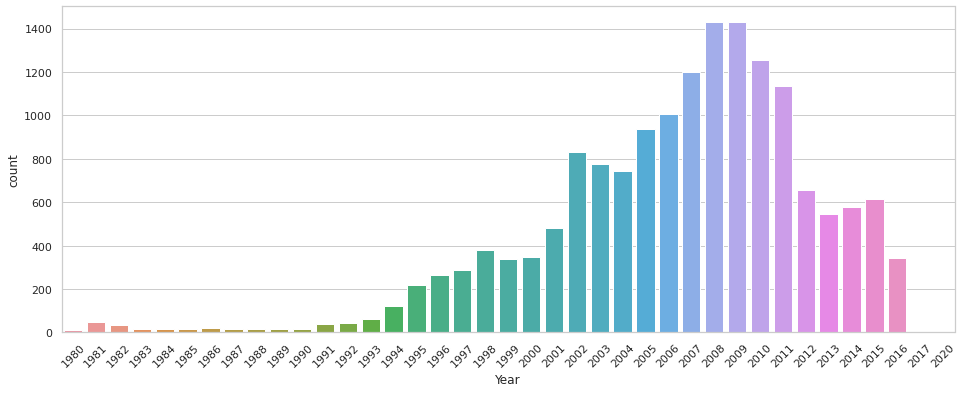

In [8]:
sns.countplot(games.Year)
plt.xticks(rotation=45)

In [ ]:
games.query("Year <= 2007").shape[0]/16291, games.query("Year > 2007").shape[0]/ 16291

In [9]:
games.Year.describe()  # 50%       2007

count    16291.000000
mean      2006.405561
std          5.832412
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2020.000000
Name: Year, dtype: float64

In [ ]:
ss.mode(games.Year)

In [ ]:
year_count = games.Year.value_counts().reset_index()
year_count.columns = ['year', 'cnt']
year_count.head(3)

# 4

На каких платформах произошло больше всего релизов?

Оставьте названия тех платформ, частота встречаемости которых составляет более 7%. Значения укажите в порядке убывания через запятую. 

In [ ]:
platforms = games.Platform.value_counts(normalize=True).mul(100).to_frame('pct')
platforms.query("pct > 7").index.to_list()

# 5

Игры какого издателя встречаются в датасет чаще всего?

Hint: value_counts


In [ ]:
games.Publisher.value_counts().head(10)

In [ ]:
ss.mode(games.Publisher)

In [ ]:
games.Publisher.describe()

# 6

Сфокусируемся на играх от Nintendo. Посчитайте среднее, медиану и стандартное отклонение по продажам игр данного издателя в разных регионах (NA, EU, JP, Other). 

В каком регионе медианное значение объема продаж является наибольшим?

Hint: mean, median, std. Переменные: NA_sales и т.д. для нужных регионов.

In [ ]:
games[['NA_Sales', 'EU_Sales','JP_Sales','Other_Sales','Global_Sales']].agg(['mean', 'median', 'std'])

In [ ]:
games[['NA_Sales', 'EU_Sales','JP_Sales','Other_Sales','Global_Sales']].describe()

# 7


Теперь посмотрим на продажи игр Nintendo в Японии по жанрам. Постройте боксплот, где по оси х будет расположен жанр игры, а по оси у - объем продаж в Японии.

Взглянем на получившиеся боксплоты. Что мы можем по ним сказать о данных?

Для удобства можете указать размер графика, например:

    plt.figure(figsize=(16,16))
    
- **Медианное значение продаж игр жанра Fighting выше, чем у игр Simulation**
- **Межквартильный размах у Strategy меньше, чем у Puzzle**
- **Наибольший межквартильный размах наблюдается у игр жанра Fighting**
- Наибольший межквартильный размах наблюдается у игр жанра Role-Playing
- Среднее значение продаж игр жанра Fighting выше, чем у игр Simulation

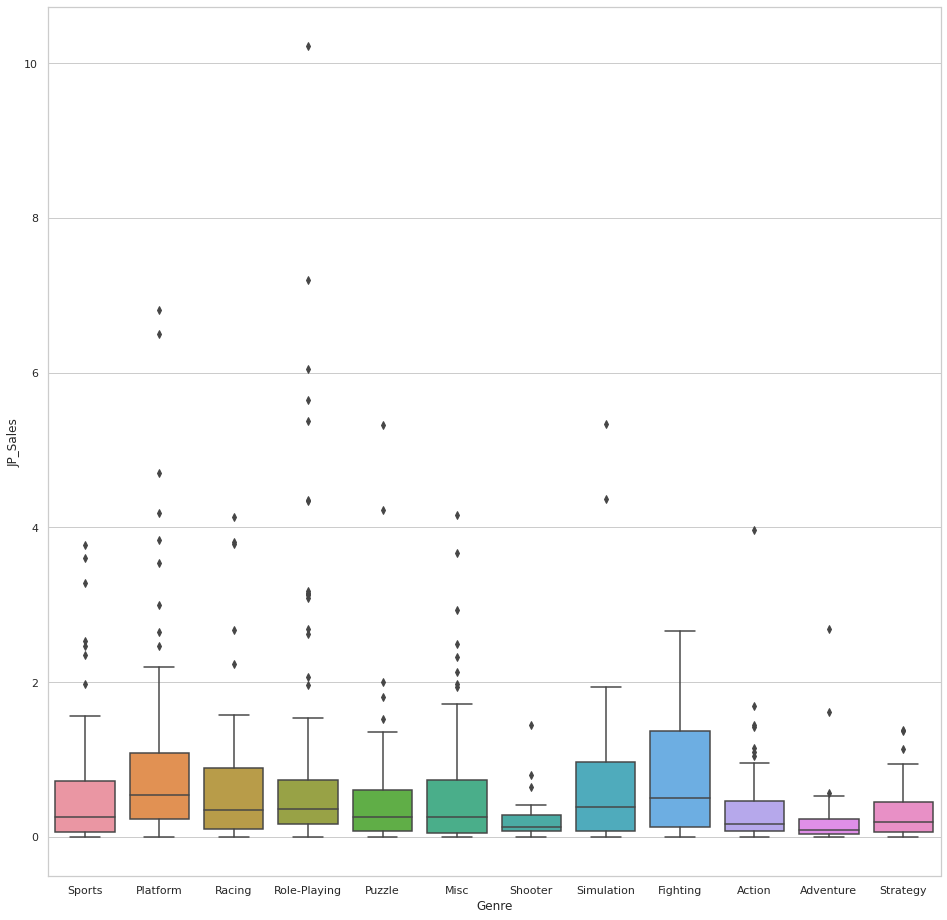

In [8]:
plt.figure(figsize=(16,16))
sns.boxplot(data=games.query("Publisher=='Nintendo'"), x='Genre', y='JP_Sales')

In [ ]:
(games.query("Publisher=='Nintendo' and Genre in ['Simulation', 'Fighting']")
      .groupby("Genre").agg({"JP_Sales" : "mean"}))

In [ ]:
#ещё можно нарисовать скрипки
sns.violinplot(data=games.query("Publisher=='Nintendo'"), x='Genre', y='JP_Sales')

In [ ]:
#а также "рой"
sns.swarmplot(data=games.query("Publisher=='Nintendo'"), x='Genre', y='JP_Sales')

# 8

Визуализируйте динамику изменения объема продаж по годам для игр следующих жанров: 'Fighting', 'Simulation', 'Platform', 'Racing', 'Sports'. На каком отрезке времени было продано наибольшее число копий игр жанра Sports? Иными словами, выберите отрезок, который включает в себя несколько крупных пиков.

In [ ]:
df = (games.query("Publisher=='Nintendo'")
      .query("Genre in ('Fighting', 'Simulation', 'Platform', 'Racing', 'Sports')")
      .groupby(['Genre', 'Year']).Global_Sales.sum().reset_index())

In [ ]:
df

In [ ]:
sns.lineplot(data=df, x='Year', y='Global_Sales', hue='Genre') #2005-2010